<a href="https://colab.research.google.com/github/alexandraf99/Data-Set-Salary-2024-by-Job-Role/blob/main/FinalProject_Alexandra_Flores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Set Salary 2024

The dataset I chose is Salary Insights by Job Role https://www.kaggle.com/datasets/zahranusrat/salary . The dataset contains information from professionals working in various different job roles in the data field during 2024. I chose this dataset because it could allow me to make informed decisions and further guide me in the career path i want to go into. Some analytical questions to guide my exploration would be what specific job titles within the data field makes the most in median salary, what location offers the highest salary when adjusted for the cost of living, and the average salary for data anaylsts.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# load in dataset
salary = pd.read_csv("/content/Dataset salary 2024.csv")

In [ ]:
# The first five rows
salary.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,202730,US,0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,92118,US,0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,130500,US,0,US,M
3,2024,SE,FT,Data Engineer,96000,USD,96000,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,190000,USD,190000,US,0,US,M


In [ ]:
# find the columns and rows
salary.shape

(16534, 11)

### The dataset has **16534 row**s and **11 columns** making it large enought to have a meaningful analysis.

In [ ]:
# display salary info
salary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16534 entries, 0 to 16533
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           16534 non-null  int64 
 1   experience_level    16534 non-null  object
 2   employment_type     16534 non-null  object
 3   job_title           16534 non-null  object
 4   salary              16534 non-null  int64 
 5   salary_currency     16534 non-null  object
 6   salary_in_usd       16534 non-null  int64 
 7   employee_residence  16534 non-null  object
 8   remote_ratio        16534 non-null  int64 
 9   company_location    16534 non-null  object
 10  company_size        16534 non-null  object
dtypes: int64(4), object(7)
memory usage: 1.4+ MB


In [ ]:
# describe the data set
salary.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,16534.000000,1.653400e+04,16534.000000,16534.000000
mean,2023.226866,1.637270e+05,149686.777973,32.003750
std,0.713558,3.402057e+05,68505.293156,46.245158
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2023.000000,1.017630e+05,101125.000000,0.000000
50%,2023.000000,1.422000e+05,141300.000000,0.000000
75%,2024.000000,1.872000e+05,185900.000000,100.000000
max,2024.000000,3.040000e+07,800000.000000,100.000000


According to the table above, the mean salary in US dollars of all the jobs in data fields would be **149,688.78**. But the standard deviation is **68505**, so there is variation and it could depend on different facts most likely, depends on the job title and experience. So to get a better analysis of what the mean is we can look at specific job titles and find a mean or median value.

In [ ]:
# checking for null values
salary.isnull()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
16529,False,False,False,False,False,False,False,False,False,False,False
16530,False,False,False,False,False,False,False,False,False,False,False
16531,False,False,False,False,False,False,False,False,False,False,False
16532,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
# sum per column for null values
salary.isnull().sum()

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


The dataset has no null values making it more accurate and easier to use.






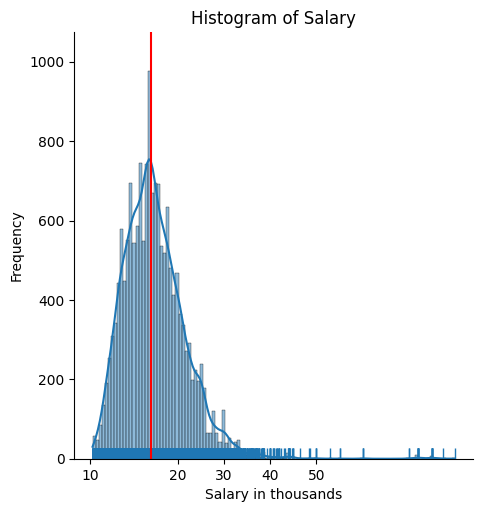

In [ ]:
# create histogram of salary column and median
sns.displot(salary['salary_in_usd'], kde=True, rug=True)
plt.axvline(salary['salary_in_usd'].median(), color='r')


plt.title("Histogram of Salary")
plt.xlabel("Salary in thousands")
plt.ylabel("Frequency")
sns.despine()

# create labels for the values
plt.xticks(
  ticks=[10000, 200000, 300000, 400000, 500000,],  # Desired tick positions
  labels=['10', '20', '30', '40', '50'] # Custom labels
    )
plt.show()

# Analytical Question 1:


---



### What specific job titles within the data field makes the most in median salary?

In [ ]:

# median salary
median_salary = salary.groupby('job_title')['salary_in_usd'].median().sort_values(ascending=False)

In [ ]:
median_salary

,salary_in_usd
job_title,
Analytics Engineering Manager,399880.0
Data Science Tech Lead,375000.0
Head of Machine Learning,330000.0
Managing Director Data Science,280000.0
AWS Data Architect,258000.0
...,...
Insight Analyst,50838.0
Compliance Data Analyst,45000.0
Staff Data Analyst,44753.0


I used `groupby with 'job_title' and 'salary'` to get the median and then sorted it in order from the highest to lowest with `.sort_values. ` I used the median to get a more true representation of a middle value in the dataset. According to the median, **Analytics Engineering Manager** makes the most in salary,with **Data Science Tech Lead** following it. But, I still want to get the mean just to compare.

In [ ]:

# mean salary
mean_salary = salary.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False)

In [ ]:
mean_salary

,salary_in_usd
job_title,
Analytics Engineering Manager,399880.000000
Data Science Tech Lead,375000.000000
Head of Machine Learning,299758.428571
Managing Director Data Science,280000.000000
AWS Data Architect,258000.000000
...,...
Quantitative Research Analyst,51000.000000
Insight Analyst,50090.642857
Compliance Data Analyst,45000.000000


In [ ]:

# mean and max for each job
salaries_agg = salary.groupby('job_title').agg({
    'salary_in_usd': ['mean','max'],

})

salaries_agg

salary_in_usd        
                                          mean     max
job_title                                             
AI Architect                     252551.241379  800000
AI Developer                     135466.789474  275000
AI Engineer                      162730.508333  400000
AI Product Manager               141766.666667  212000
AI Programmer                     62042.000000  120000
...                                        ...     ...
Sales Data Analyst                60000.000000   60000
Software Data Engineer           111627.666667  210000
Staff Data Analyst                79917.000000  179998
Staff Data Scientist             134500.000000  164000
Staff Machine Learning Engineer  185000.000000  185000

[155 rows x 2 columns]

In [ ]:

# Data Analyst list , mean salary, median
data_analyst=['MDDS', 'Head of Machine', 'Data Science', 'Analytics']
salary_mean = [280000, 299758.43, 375000, 399880.00]
salary_median=[280000, 330000, 375000, 399880]

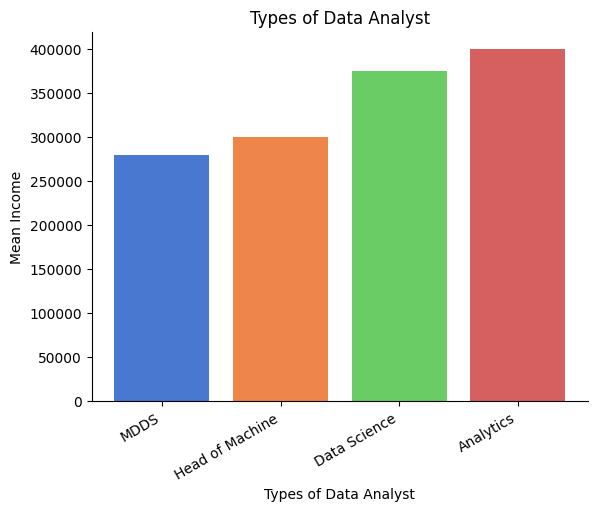

In [ ]:

# bar graph using Data Analyst and Salary list
import matplotlib.pyplot as plt
plt.bar(data_analyst, salary_mean,color = colors)
colors = sns.color_palette("muted")
plt.xlabel('Types of Data Analyst')
plt.ylabel('Mean Income')
plt.xticks(rotation=30, ha='right')
plt.title('Types of Data Analyst')
sns.despine()
plt.show()


This bar graph portrays that the mean income of Analytics is the highest with Data Science following and Head of Machine, and last MDDS.

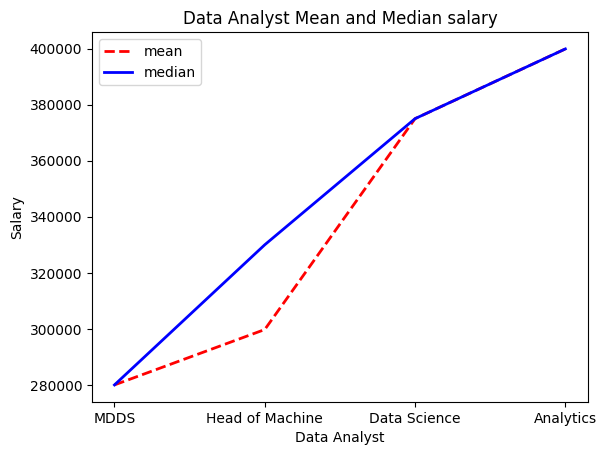

<Figure size 640x480 with 0 Axes>

In [ ]:
# multi_line plot using salary(mean) and Salary_median
plt.plot(data_analyst, salary_mean, color='r', linestyle = '--', linewidth = 2, label='mean')
plt.plot(data_analyst, salary_median, color='b', linestyle = '-', linewidth = 2, label='median')
plt.xlabel("Data Analyst")
plt.ylabel("Salary")
plt.title("Data Analyst Mean and Median salary")
plt.legend()


sns.despine()
plt.savefig('q1_sales_trend.png')
plt.show()

According to the data, **Analytics Engineering Manager** makes the most in  salary., with **Data Science Tech Lead** following it.






# Analytical Question 2:


---



### What is the average salary for **Data Analysts**.

I used `groupby with 'job_title' `and` 'salary_in_usd'` to find the mean and I used `'.sort_values(ascending=False)`' to sort the column from highest to lowest. Then i used `'filter(like='Data Analyst')'` to grab all of the job titles containing Data Analyst. Then, I also used
`'loc['Data Analyst']` so that I could get the mean of just a normal Data Analyst, which is $**107921**.






In [ ]:

# mean value of each job title
data_analyst_mean = salary.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False)


# job titles containing Data Analyst
data_analyst_mean = data_analyst_mean.filter(like='Data Analyst').head()

In [ ]:
# mean salary of 'Data Analyst'
data_analyst_mean.loc['Data Analyst']

np.float64(107921.1344262295)

In [ ]:
data_analyst_mean

,salary_in_usd
job_title,
Marketing Data Analyst,144327.000000
Finance Data Analyst,141933.666667
Principal Data Analyst,122500.000000
Data Analyst,107921.134426
Financial Data Analyst,90375.000000


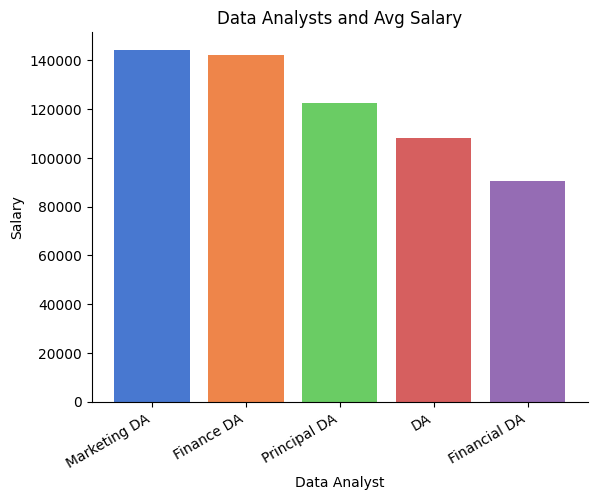

In [ ]:
# create a dictionary of Data Analysts and corresponding salary
salary_dict = {
        'Marketing DA': 144327,
        'Finance DA': 141933,
        'Principal DA': 122500,
        'DA':107921,
         'Financial DA':90375
}

colors = sns.color_palette("muted")

# turn dictionary into list
job_title = list(salary_dict.keys())
values = list(salary_dict.values())

# Add labels and title
plt.xlabel("Data Analyst")
plt.ylabel("Salary")
plt.title("Data Analysts and Avg Salary")
plt.xticks(rotation=30, ha='right')

# bar graph
plt.bar(job_title, values,color=colors)
sns.despine()
plt.show()

This visualization portrays that **Marketing Data Analyst** makes the highest in salary with **Finance Data Analyst** in second, **Principal Data Analyst** in third, **Data Analyst** in fourth, and **Financial Data Analyst** in fifth.

## Analytical Question 3:


---



## What location offers the highest salary for each job title


I used `groupby `with` 'job_title' `and` 'salary_in_usd'`for the columns.I used the `idx.max()` function to find the highest paying and location for each and the `.sort_values` to sort from highest to lowest for the salary. So, according to the data table those are the highest values for each job title and the company location of the job. They are also sorted in order from highest value in the column to lowest. For 'Data Analyst' the company location is CA and the salary is $800000.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# find top salaries using groupby
top_salaries = salary.loc[salary.groupby('job_title')['salary_in_usd'].idxmax()]

# sort them by highest to lowest
top_salaries = top_salaries[['job_title', 'salary_in_usd', 'company_location']].sort_values(by='salary_in_usd',ascending=False)


top_salaries.head()



,job_title,salary_in_usd,company_location
2804,AI Architect,800000,CA
3647,Data Analyst,774000,MX
4446,Analytics Engineer,750000,US
6412,Machine Learning Engineer,750000,US
7498,Data Scientist,750000,US


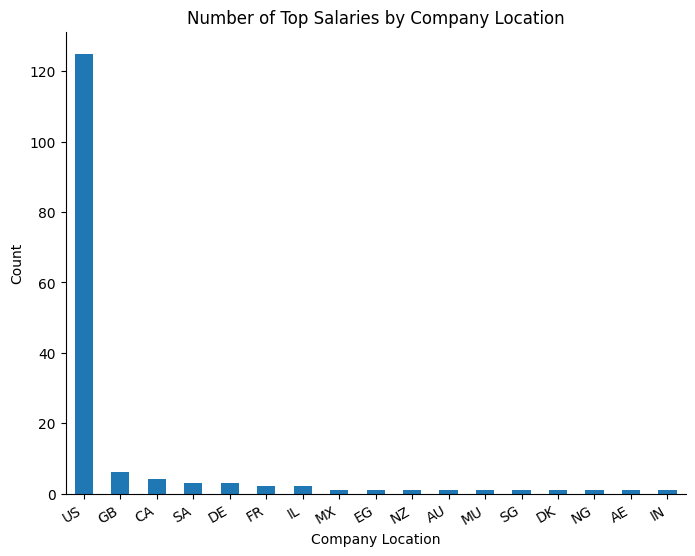

In [ ]:

counts = top_salaries['company_location'].value_counts()


plt.figure(figsize=(8,6))
counts.plot(kind='bar')
plt.xticks(rotation=30, ha='right')
# Add labels and title
plt.xlabel("Company Location")
plt.ylabel("Count")
plt.title("Number of Top Salaries by Company Location")

sns.despine()
plt.show()

This visualization shows that the **US** has the highest salary for many more jobs than any other locations with **Great Britain** coming in second.

In [ ]:

# list of salaries and corresponding locations
top_salary_list = [800000, 77400, 750000, 750000, 750000]
top_salary_location = ['CA', 'MX', 'US', 'US', 'US']



def cost_of_living(x,y):
  """

    finds the location and corresponding values and then subtracts
    the cost of living to find the adjust salary

  """

  # empty list to add adjusted salary to
  new_salary = []


  for location, salary in zip(x, y):

    if location == 'US':
        salary -= 77280

    elif location == 'CA':
        salary -= 39924

    elif location == 'MX':
      salary -= 18000

    new_salary.append(salary)

  return new_salary


cost_of_living(top_salary_location,top_salary_list)


[760076, 59400, 672720, 672720, 672720]

/tmp/ipython-input-4058132235.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_salary_location, y=adjusted_salary, palette='viridis')


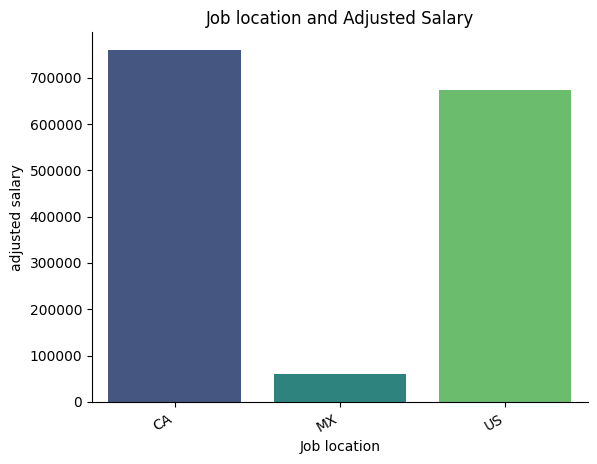

In [ ]:
adjusted_salary = [760076, 59400, 672720, 672720, 672720]

# bar plot using names and values list
sns.barplot(x=top_salary_location, y=adjusted_salary, palette='viridis')

plt.xlabel("Job location")
plt.ylabel("adjusted salary")
plt.title('Job location and Adjusted Salary')
plt.xticks(rotation=30, ha='right')


sns.despine()
plt.show()

This visualization shows with the adjusted salary for the cost of living **Canada** actually has the highest salary, with **United States** coming in second.

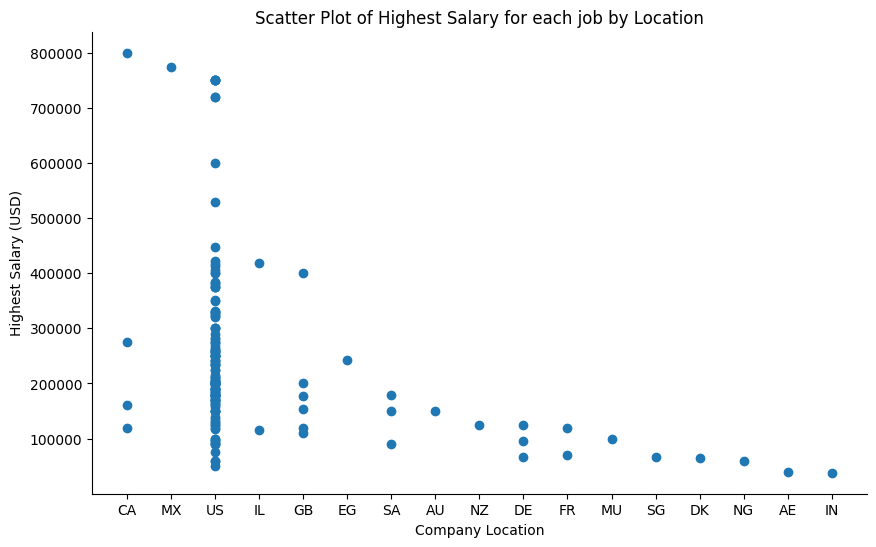

In [ ]:

plt.figure(figsize=(10,6))

plt.scatter(top_salaries['company_location'], top_salaries['salary_in_usd'])

plt.xlabel("Company Location")
plt.ylabel("Highest Salary (USD)")
plt.title("Scatter Plot of Highest Salary for each job by Location")
sns.despine()
plt.show()

This visualization shows that Canada has one job with the highessts salary, but the majority of the jobs with the highest salary is the US. This visualization contributes to the data because it cleary shows how Canada has only one job with a high paying salary. But overall most of the jobs are located in the United States.

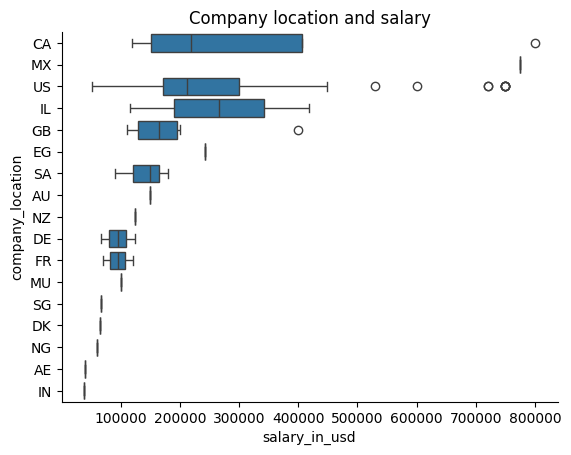

In [ ]:
sns.boxplot(x='salary_in_usd', y='company_location', data=top_salaries)

plt.title('Company location and salary')

sns.despine()

This visualization shows that salary for Canada seems to be the highest,due to the outlier. But the mean of jobs in Canada and US are pretty close.

## Findings and Conclusions

According to the data, some key take aways I found was that the mean income of **Analytics** is the highest with **Data Science** following and **Head of Machine**.I found that for Data Analysts fields, the **Marketing Data Analyst** makes the highest in mean salary with **Finance Data Analyst** in second, **Principal Data Analyst** in third, **Data Analyst** in fourth, and **Financial Data Analyst** in fifth. A Data Analyst makes an average salary of $107,921.13 .Therefore, most the other job titles make more than just a normal Data Analyst.  I found that the location that offers the highest paying salary overall is **Canada with AI Architect	at 800000**. I found that the location with highest paying salary for the most amount of jobs is the **United States**. I also found that even after the salary is adjusted for the cost of living, **Canada** still has one job with the highest paying salary, with the **US** coming in second.

In [ ]:
!jupyter nbconvert --to html /content/FinalProject_Alexandra_Flores.ipynb

[NbConvertApp] Converting notebook /content/FinalProject_Alexandra_Flores.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 8 image(s).
[NbConvertApp] Writing 674777 bytes to /content/FinalProject_Alexandra_Flores.html
